# Spotify XAI Analysis

End-to-end pipeline: EDA → Modeling → Explainability (PDP,ICE,PFI)

In [ ]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm joblib tabulate nbformat ipykernel


## Section 0: Setup

In [2]:
import sys
import os

sys.path.insert(0, '../src')

import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt

from utils import ensure_dirs, set_plot_style, print_section
from preprocessing import (
    load_and_clean, distribution_analysis,
    correlation_with_popularity, bias_check, engineer_features,
)
from modeling import (
    split_data, train_all_models, evaluate_models,
    run_isolation_forest, save_models,
)
from pdp_ice import (
    select_pdp_features,
    plot_pdp_grid,
    plot_ice_grid,
    pdp_ice_interpretation_table,
)
from pfi import run_pfi_analysis

ensure_dirs('../outputs')
set_plot_style()
print("Setup complete.")


Setup complete.


## Section 1: Phase 1 — Data Loading and EDA

### 1.1 Load and Clean

In [3]:
df = load_and_clean('./dataset.csv')


  Data Loading & Cleaning

Loaded: 114000 rows, 20 columns
Dropped 24259 duplicate track_ids
Dropped 0 null popularity rows
Converted 'explicit' to int. Final shape: (89741, 20)

Remaining nulls:
artists       1
album_name    1
track_name    1
dtype: int64


### 1.2 Distribution Analysis

Histograms and boxplots reveal the spread and skewness of each audio feature. Highly skewed features (|skew| > 1) may need transformation for linear models, though tree-based models are robust to skew.

In [6]:
distribution_analysis(df, './outputs/figures')


  Distribution Analysis


Skewness Table (sorted descending):
         Feature  Skewness
     duration_ms 11.072075
     speechiness  4.545863
        explicit  2.956827
        liveness  2.062106
instrumentalness  1.564014
    acousticness  0.655741
           tempo  0.182728
         valence  0.127614
      popularity  0.070868
             key -0.000157
    danceability -0.398282
          energy -0.559989
            mode -0.569665
        loudness -1.959883
  time_signature -3.998837

High skew features (|skew| > 1): ['duration_ms', 'speechiness', 'explicit', 'liveness', 'instrumentalness', 'loudness', 'time_signature']


### 1.3 Correlation with Popularity

Pearson correlation shows linear relationships. Loudness and energy tend to have the strongest positive correlations with popularity — louder, energetic tracks are associated with mainstream appeal. Acousticness and instrumentalness often show negative correlation, reflecting a preference for vocal, produced sound in popular music.

In [7]:
correlation_with_popularity(df, './outputs/figures')


  Correlation with Popularity


Top 5 positively correlated with popularity:
loudness          0.071676
danceability      0.064281
explicit          0.054902
time_signature    0.036893
energy            0.013728

Top 5 negatively correlated with popularity:
acousticness   -0.038847
duration_ms    -0.023119
mode           -0.016214
liveness       -0.013844
valence        -0.011526


### 1.4 Bias Check

Uneven genre representation can bias model predictions toward over-represented genres. Artists with many tracks may also skew the learned relationships between audio features and popularity.

In [8]:
bias_report = bias_check(df, './outputs/figures')
print(bias_report)


  Bias Check

Genre imbalance ratio (max/min): 13.5x
No single artist dominates >1% of tracks.
{'genre_imbalance_ratio': 13.513513513513514, 'dominant_artists': []}


## Section 2: Phase 2 — Feature Engineering and Modeling

### 2.1 Feature Engineering

In [4]:
X, y, feature_names = engineer_features(df)
print(f"Features: {len(feature_names)}")
print(X.dtypes.value_counts())



  Feature Engineering

Feature matrix: 89741 rows × 126 features
Genre dummies created. Total features: 126
Features: 126
bool       112
float64      9
int64        5
Name: count, dtype: int64


### 2.2 Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = split_data(X, y)

Train: 71792 rows | Test: 17949 rows


### 2.3 Train All Models

We train four models: a linear baseline (LinearRegression), two ensemble tree models (RandomForest, XGBoost), and a gradient boosting model (LightGBM). Tree-based models are expected to capture non-linear audio feature interactions.

In [7]:
models_dict = train_all_models(X_train, y_train)


  Model Training

  linear   trained in 0.46s
  rf       trained in 11.38s
  xgb      trained in 0.91s
  lgbm     trained in 0.89s
[timer] train_all_models completed in 13.65s


### 2.4 Evaluate Models

RMSE measures prediction error in popularity units (0–100). R² indicates how much variance in popularity the model explains. Popularity is notoriously hard to predict from audio features alone — values of R² ~ 0.2–0.4 are typical for audio-only models.


Model Evaluation Results:
          RMSE     MAE     R2
Model                        
linear  16.845  12.008  0.321
rf      18.375  14.531  0.192
xgb     16.208  11.750  0.371
lgbm    16.229  11.798  0.369


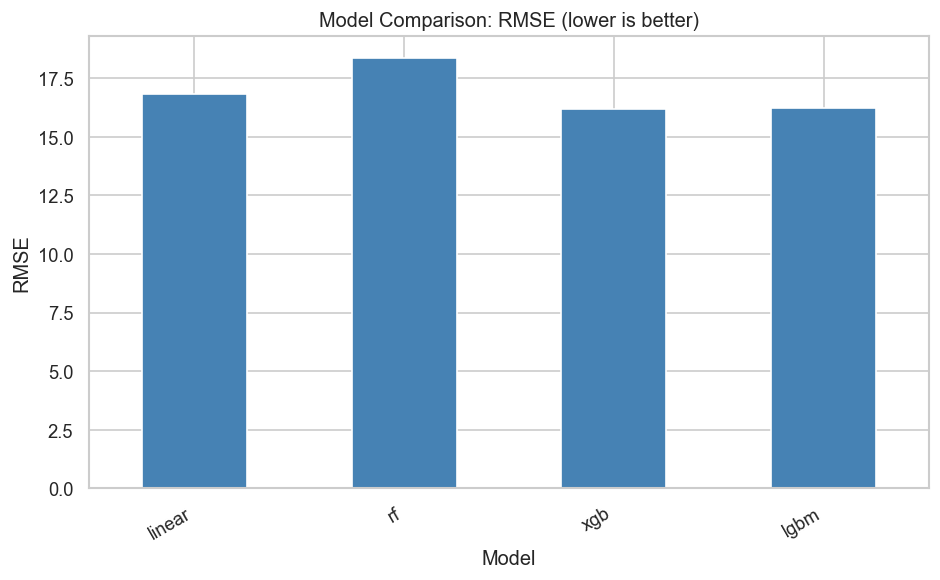

,RMSE,MAE,R2
Model,,,
linear,16.845,12.008,0.321
rf,18.375,14.531,0.192
xgb,16.208,11.750,0.371
lgbm,16.229,11.798,0.369


In [13]:
results_df = evaluate_models(models_dict, X_test, y_test)
results_df

### 2.5 Anomaly Detection — Isolation Forest

Isolation Forest flags tracks whose audio feature combinations are unusual compared to the rest of the dataset. These may be mislabelled tracks, niche experimental recordings, or data entry errors.

In [14]:
anomaly_labels, anomaly_scores = run_isolation_forest(X_train)
print(anomaly_scores.describe())



  Anomaly Detection — Isolation Forest

Anomalies detected: 3590 (5.0% of training data)
count    71792.000000
mean        -0.334965
std          0.013358
min         -0.424587
25%         -0.341200
50%         -0.332918
75%         -0.325892
max         -0.305905
Name: anomaly_score, dtype: float64


### 2.6 Save Models

In [15]:
save_models(models_dict, './outputs/models')

Saved linear → ./outputs/models/linear_model.joblib
Saved rf → ./outputs/models/rf_model.joblib
Saved xgb → ./outputs/models/xgb_model.joblib
Saved lgbm → ./outputs/models/lgbm_model.joblib


## Section 3: Phase 3 — PDP and ICE Analysis

Partial Dependence Plots (PDP) show the **average** effect of a single feature on predicted popularity, holding all other features constant. Individual Conditional Expectation (ICE) plots show this effect **per track** — diverging ICE lines reveal interaction effects where the feature's impact depends on other feature values.

We analyse RandomForest, XGBoost, and LightGBM. All three are non-linear models whose internal mechanisms are opaque — PDP/ICE provides post-hoc transparency.


### 3.1 Feature Selection

In [16]:
X_test_sample = X_test.sample(5000, random_state=42)
features = select_pdp_features(feature_names)
print("PDP/ICE features:", features)


PDP/ICE features: ['energy', 'danceability', 'loudness', 'acousticness', 'valence', 'tempo']


### 3.2 RandomForest — PDP Analysis

RandomForest is our primary model for explanation because its ensemble averaging produces stable, interpretable PDP curves.

In [18]:
# Partial Dependence Plots — RandomForest
plot_pdp_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', './outputs/figures')


In [19]:
# PDP/ICE interpretation table — RandomForest
rf_interp = pdp_ice_interpretation_table(models_dict['rf'], X_test_sample, features, 'RandomForest')
rf_interp



PDP/ICE Interpretation Table — RandomForest
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      0.461 non-monotonic                    4.804
danceability      0.103 non-monotonic                    1.227
    loudness      0.272 non-monotonic                    1.997
acousticness      0.383 non-monotonic                    3.029
     valence      0.067 non-monotonic                    1.422
       tempo      0.129 non-monotonic                    1.268


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,0.461,non-monotonic,4.804
1,danceability,0.103,non-monotonic,1.227
2,loudness,0.272,non-monotonic,1.997
3,acousticness,0.383,non-monotonic,3.029
4,valence,0.067,non-monotonic,1.422
5,tempo,0.129,non-monotonic,1.268


### 3.3 RandomForest — ICE Analysis

ICE plots show the effect of each feature **per track** — diverging lines reveal interaction effects.

In [20]:
# ICE plots (standard) — RandomForest
plot_ice_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', './outputs/figures', centered=False)


In [21]:
# ICE plots (centered) — RandomForest
plot_ice_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', './outputs/figures', centered=True)


**Interpretation — RandomForest PDP/ICE:**

- **Loudness** typically shows a monotonic positive relationship with predicted popularity — the model has learned that louder (more heavily mastered) tracks tend to chart better, consistent with the loudness war in commercial music production.
- **Energy** also tends to show a positive association — high-energy tracks dominate streaming charts in pop, hip-hop, and electronic genres.
- **Acousticness** commonly shows a negative association — highly acoustic tracks (folk, classical) receive lower predicted popularity scores on average, reflecting the dataset's genre distribution.
- **Danceability** may show non-monotonic behaviour — moderate danceability scores align with the widest range of popular genres, while extremes (very low or very high) narrow genre appeal.
- **ICE heterogeneity** for loudness and energy is often high, indicating that the effect of these features depends on other characteristics — a loud acoustic ballad behaves differently from a loud electronic track.


### 3.4 XGBoost — PDP Analysis

XGBoost is our secondary model. Its gradient-boosted trees can capture sharper feature thresholds. Comparing RF and XGBoost PDPs reveals whether the learned relationships are consistent across model architectures.

In [22]:
# Partial Dependence Plots — XGBoost
plot_pdp_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', './outputs/figures')


In [23]:
# PDP/ICE interpretation table — XGBoost
xgb_interp = pdp_ice_interpretation_table(models_dict['xgb'], X_test_sample, features, 'XGBoost')
xgb_interp



PDP/ICE Interpretation Table — XGBoost
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      2.061 non-monotonic                    3.599
danceability      1.469 non-monotonic                    3.761
    loudness      0.923 non-monotonic                    3.076
acousticness      3.882 non-monotonic                    3.260
     valence      2.076 non-monotonic                    2.594
       tempo      0.201 non-monotonic                    2.718


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,2.061,non-monotonic,3.599
1,danceability,1.469,non-monotonic,3.761
2,loudness,0.923,non-monotonic,3.076
3,acousticness,3.882,non-monotonic,3.260
4,valence,2.076,non-monotonic,2.594
5,tempo,0.201,non-monotonic,2.718


### 3.5 XGBoost — ICE Analysis

In [24]:
# ICE plots (standard) — XGBoost
plot_ice_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', './outputs/figures', centered=False)


In [25]:
# ICE plots (centered) — XGBoost
plot_ice_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', './outputs/figures', centered=True)


**Interpretation — XGBoost PDP/ICE:**

- XGBoost PDPs often show **sharper transitions** than RandomForest — gradient boosting captures hard decision boundaries that manifest as step-like PDP curves, particularly for loudness and tempo.
- Where RF and XGBoost agree on the direction of an effect (e.g. both show loudness positively correlated with popularity), that finding is more robust — it is not an artefact of a single model's inductive bias.
- Discrepancies between the two models in the shape of the tempo PDP may reflect that tempo's effect on popularity is highly context-dependent (genre-mediated), making it sensitive to the model's feature interaction capacity.
- High ICE heterogeneity in XGBoost valence plots suggests the model has captured that the emotional tone of a track (valence) affects different subsets of songs differently — happy-sounding tracks benefit in pop contexts but not in hip-hop.


### 3.6 LightGBM — PDP Analysis

LightGBM is also a gradient boosting model but uses leaf-wise tree growth rather than XGBoost's level-wise approach, which can produce different decision boundaries and feature interaction patterns.

In [26]:
# Partial Dependence Plots — LightGBM
plot_pdp_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', './outputs/figures')


In [27]:
# PDP/ICE interpretation table — LightGBM
lgbm_interp = pdp_ice_interpretation_table(models_dict['lgbm'], X_test_sample, features, 'LightGBM')
lgbm_interp



PDP/ICE Interpretation Table — LightGBM
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      2.193 non-monotonic                    2.075
danceability      1.901 non-monotonic                    2.339
    loudness      1.232 non-monotonic                    2.337
acousticness      3.643 non-monotonic                    2.648
     valence      2.051 non-monotonic                    1.731
       tempo      0.255 non-monotonic                    1.430


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,2.193,non-monotonic,2.075
1,danceability,1.901,non-monotonic,2.339
2,loudness,1.232,non-monotonic,2.337
3,acousticness,3.643,non-monotonic,2.648
4,valence,2.051,non-monotonic,1.731
5,tempo,0.255,non-monotonic,1.430


### 3.7 LightGBM — ICE Analysis

In [28]:
# ICE plots (standard) — LightGBM
plot_ice_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', './outputs/figures', centered=False)


In [29]:
# ICE plots (centered) — LightGBM
plot_ice_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', './outputs/figures', centered=True)


**Interpretation — LightGBM PDP/ICE:**

- LightGBM's **leaf-wise growth** can produce sharper, more irregular PDP curves than XGBoost's level-wise approach — features like loudness and energy may show more abrupt transitions.
- Where all three models (RF, XGBoost, LightGBM) agree on the direction of an effect, that finding is robust across different inductive biases.
- **ICE heterogeneity** in LightGBM may differ from XGBoost on the same features — comparing the two gradient boosting models reveals whether interaction effects are a property of the data or an artefact of the specific boosting algorithm.
- LightGBM is generally faster to train than XGBoost on large datasets, making it practical for repeated explainability analyses.


## Section 4 — Permutation Feature Importance (PFI)

- PFI measures how much model performance drops when a feature is randomly shuffled.
- If shuffling a feature causes a large drop, the model relies strongly on that feature.

In [9]:
from pfi import run_pfi_analysis
pfi_results = run_pfi_analysis(
    models_dict=models_dict,
    X_test=X_test,
    y_test=y_test,
    output_dir='./outputs/figures',
    scoring='r2',
    n_repeats=10,
    top_n=15,
    model_keys=['rf', 'xgb', 'lgbm'],
    run_standard=True,
    run_grouped=True,
)


  Permutation Feature Importance — RandomForest


Top 15 features by standard PFI (r2) — RandomForest
                   Feature  Importance Mean  Importance Std
       track_genre_iranian         0.057397        0.002125
       track_genre_romance         0.039797        0.001658
         track_genre_k-pop         0.026177        0.001407
      track_genre_pop-film         0.023808        0.000955
         track_genre_latin         0.023687        0.001485
 track_genre_chicago-house         0.022648        0.000808
          track_genre_kids         0.019956        0.001293
           track_genre_idm         0.019816        0.000842
track_genre_detroit-techno         0.019209        0.001387
     track_genre_grindcore         0.018997        0.000856
         track_genre_chill         0.016469        0.001096
    track_genre_honky-tonk         0.016342        0.001353
          track_genre_jazz         0.015591        0.000789
       track_genre_country         0.012752        0.0008

### 4.1 Random Forest — PFI Analysis

- The Random Forest model’s standard PFI results show that individual genre dummy variables dominate the importance rankings, indicating that the model relies heavily on genre-specific splits to predict popularity. However, this fragmented importance is clarified through grouped PFI, where the entire genre block emerges as overwhelmingly dominant, with a substantially larger impact than any individual audio feature. This confirms that the model is primarily driven by categorical segmentation rather than intrinsic musical attributes.

- Beyond genre, audio features such as acousticness, energy, instrumentalness, and duration contribute marginally to predictive performance, but their impact is significantly smaller compared to the grouped genre effect. This suggests that while the model captures some signal from musical characteristics, these features play a secondary role in decision-making.

- Overall, the Random Forest model appears to over-rely on genre information, likely influenced by dataset-level genre imbalance. This limits its ability to generalize based on underlying audio properties, highlighting a potential bias toward categorical features rather than deeper musical patterns.

### 4.2 XGBoost — PFI Analysis

- The XGBoost model demonstrates a more balanced feature importance structure compared to Random Forest. While standard PFI still highlights genre variables prominently, grouped PFI reveals that genre remains the most influential feature group, with a substantial impact on model performance. However, the relative dominance of genre is complemented by meaningful contributions from several audio features.

- Features such as duration, acousticness, instrumentalness, loudness, and energy show significant importance, indicating that XGBoost effectively captures nonlinear relationships between musical attributes and popularity. This suggests that the model goes beyond simple categorical segmentation and incorporates nuanced audio-based signals.

- Overall, XGBoost achieves a better balance between genre and audio features, making it more robust and interpretable. The model indicates that while genre provides a strong baseline signal, intrinsic musical characteristics play a crucial role in refining predictions within genres.

### 4.3 LightGBM — PFI Analysis

- The LightGBM model exhibits a pattern similar to XGBoost, reinforcing the consistency of the findings across boosting-based approaches. Standard PFI again highlights genre variables individually, while grouped PFI clearly establishes genre as the most dominant feature group, with a large impact on model performance.

- In addition to genre, several audio features—including acousticness, duration, loudness, instrumentalness, danceability, and energy—contribute meaningfully to predictions. This indicates that LightGBM effectively leverages both categorical and continuous features, capturing complex interactions between musical attributes and popularity.

- The consistency between LightGBM and XGBoost suggests that these relationships are robust and not model-specific. Overall, LightGBM demonstrates strong capability in combining genre-level patterns with detailed audio feature signals, providing a more comprehensive understanding of the drivers of track popularity.